# 1. Import Necessary libraries

In [17]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

## 2. Import Dataset

In [2]:
cars_data = pd.read_csv(filepath_or_buffer = "Cars.csv")

## 3. Data Understanding 

### 3.1 Perform Initial Investigation on the data 

In [3]:
cars_data.shape

(81, 5)

In [4]:
cars_data.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [5]:
cars_data.isnull().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [6]:
cars_data.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [7]:
cars_data.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


## Lets check for the Assumptions

## Test 1: Linearity Test

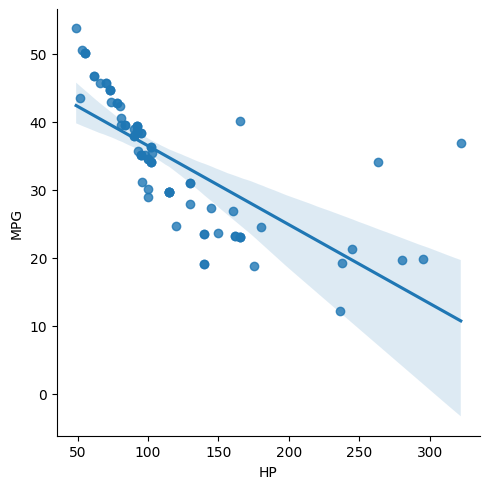

In [8]:
sns.lmplot(data= cars_data, x="HP", y="MPG")

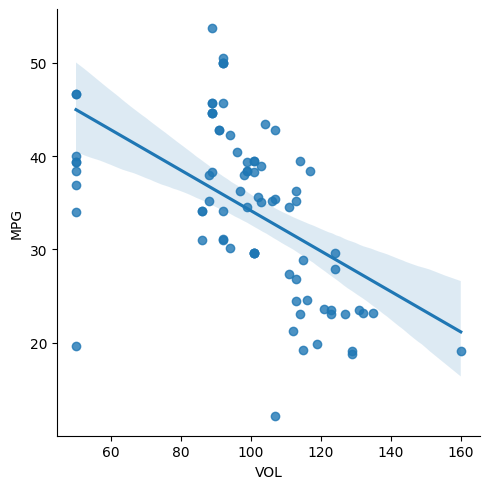

In [9]:
sns.lmplot(data= cars_data, x="VOL", y="MPG")

<Axes: xlabel='HP', ylabel='MPG'>

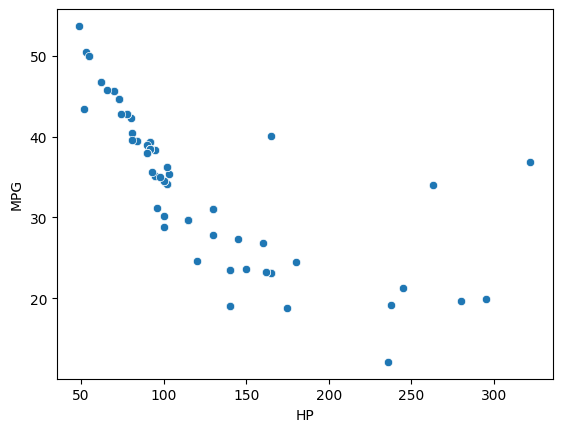

In [10]:
sns.scatterplot(data= cars_data, x="HP", y="MPG")

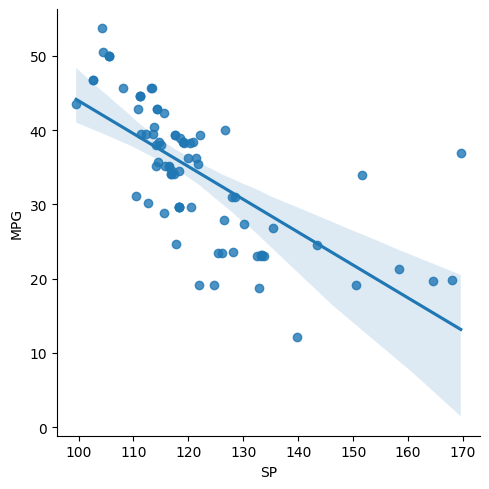

In [11]:
sns.lmplot(data= cars_data, x="SP", y="MPG")

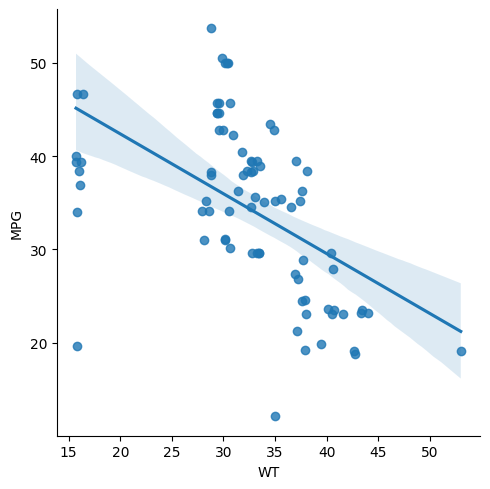

In [12]:
sns.lmplot(data= cars_data, x="WT", y="MPG")

## Test 1 Linearity failed

## Test 2 Normality Test

(array([15., 35.,  9.,  6.,  9.,  0.,  2.,  2.,  1.,  2.]),
 array([ 49. ,  76.3, 103.6, 130.9, 158.2, 185.5, 212.8, 240.1, 267.4,
        294.7, 322. ]),
 <BarContainer object of 10 artists>)

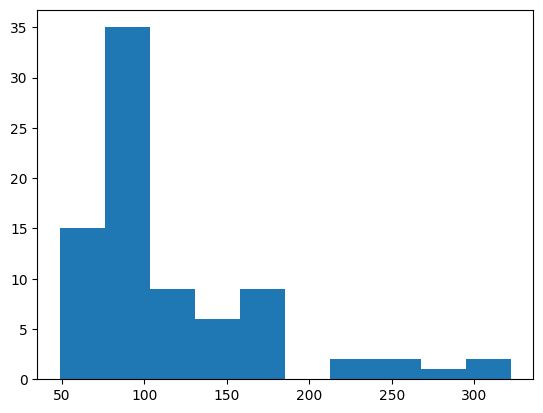

In [13]:
plt.hist(cars_data["HP"])

Text(0.5, 1.0, 'HP Distriubution')

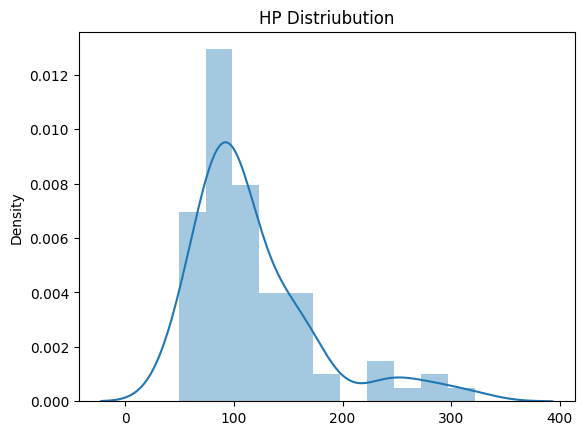

In [14]:
sns.distplot(x=cars_data["HP"])
plt.title("HP Distriubution")

(array([ 8., 12., 32., 10., 10.,  2.,  1.,  2.,  1.,  3.]),
 array([ 99.56490661, 106.56826723, 113.57162785, 120.57498847,
        127.57834909, 134.58170971, 141.58507032, 148.58843094,
        155.59179156, 162.59515218, 169.5985128 ]),
 <BarContainer object of 10 artists>)

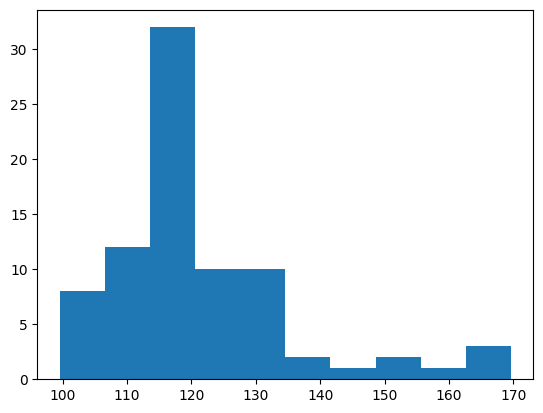

In [15]:
plt.hist(cars_data["SP"])

(array([ 9.,  0.,  0., 22., 20., 15.,  8.,  6.,  0.,  1.]),
 array([ 50.,  61.,  72.,  83.,  94., 105., 116., 127., 138., 149., 160.]),
 <BarContainer object of 10 artists>)

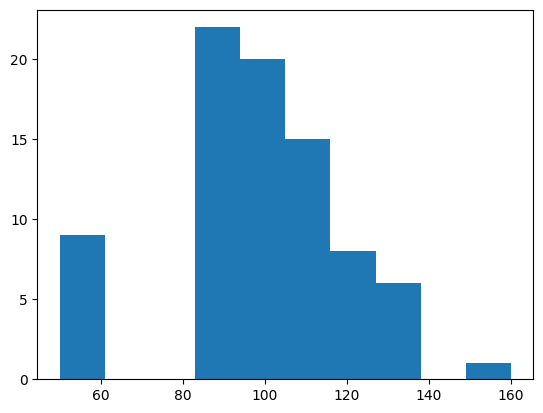

In [16]:
plt.hist(cars_data["VOL"])

(array([ 9.,  0.,  0., 22., 19., 18.,  7.,  5.,  0.,  1.]),
 array([15.71285853, 19.44134791, 23.1698373 , 26.89832668, 30.62681606,
        34.35530544, 38.08379483, 41.81228421, 45.54077359, 49.26926298,
        52.99775236]),
 <BarContainer object of 10 artists>)

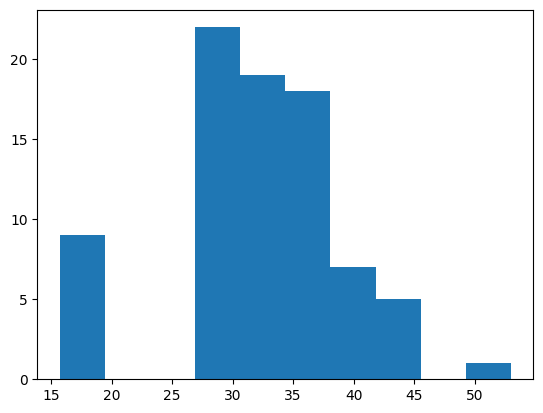

In [17]:
plt.hist(cars_data["WT"])

## Test 3 Normality also failed

## correlation function

In [3]:
corr_matrix = cars_data.corr()
corr_matrix

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


<Axes: >

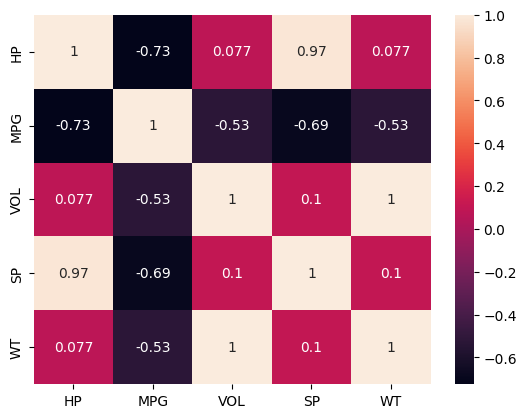

In [4]:
sns.heatmap(data = corr_matrix, annot=True)

## Test 3 - There is Multi correlation

## Test 4 - AutoRegression passed - Which means there is no time , date date in the dataset

## 4. Data Preparation

In [20]:
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


## 4. Data Prepation

In [7]:
X= cars_data[["HP","VOL","SP","WT"]]
X

,HP,VOL,SP,WT
0,49,89,104.185353,28.762059
1,55,92,105.461264,30.466833
2,55,92,105.461264,30.193597
3,70,92,113.461264,30.632114
4,53,92,104.461264,29.889149
...,...,...,...,...
76,322,50,169.598513,16.132947
77,238,115,150.576579,37.923113
78,263,50,151.598513,15.769625
79,295,119,167.944460,39.423099


In [8]:
y = cars_data["MPG"]
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

## There is nothing to prepare because all features as numbers

## 5. Model builing

In [18]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [19]:
linear_model = LinearRegression()

## Train_test_split

In [9]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size =0.20, shuffle=True,random_state=42)

In [10]:
X_train,X_test

(     HP  VOL          SP         WT
 61  120  116  117.668550  37.860411
 55  130  124  126.404312  40.589068
 40   95  113  116.392639  37.392524
 9    80   94  115.645204  30.920154
 64  150  121  128.128401  40.159482
 ..  ...  ...         ...        ...
 20   92   99  119.105055  32.324650
 60  145  111  130.208698  36.888153
 71  162  135  133.415985  44.013139
 14   66   89  108.185353  29.347279
 51  115  101  118.288996  33.436711
 
 [64 rows x 4 columns],
      HP  VOL          SP         WT
 30   84  114  113.484609  37.042350
 0    49   89  104.185353  28.762059
 22   95  101  120.288996  32.675828
 31   84  101  112.288996  33.234361
 18   78   91  114.369293  29.929394
 28   52  104   99.564907  34.483207
 10   73   89  111.185353  29.363341
 70  280   50  164.598513  15.823060
 4    53   92  104.461264  29.889149
 12   92   99  122.105055  32.813592
 49  115  101  118.288996  33.458472
 33  102  113  121.392639  37.573290
 67  165  127  133.680223  41.573975
 35   90   9

## 6. Model training

In [29]:
linear_model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-0.22,-0.54, 0.53, 0.95]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['HP','VOL','SP','WT']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,17.73
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


## check the slope and intercept

In [30]:
linear_model.intercept_

np.float64(17.725737079015556)

In [31]:
linear_model.coef_

array([-0.22051886, -0.53968773,  0.53363516,  0.94526434])

## 7. Model Testing

In [32]:
y_pred =linear_model.predict(X_train)
y_pred

array([27.23986964, 27.95819115, 33.24875655, 40.29364807, 25.68083894,
       42.62893641, 34.73507363, 35.65466797, 24.43365831, 37.11949077,
       28.9235271 , 40.36428199, 36.42550725, 34.34806727, 15.59635557,
       46.79967595, 32.37674121, 29.12848417, 37.19492862, 26.41526801,
       46.77245271, 34.47509096, 40.69845435, 19.37848349, 42.14051045,
       48.51604266, 38.27005071, 47.28339177, 36.7659616 , 40.87329203,
       38.45089108, 22.79128741, 33.99418186, 33.34967248, 15.33615265,
       40.91216943, 38.60538243, 34.44714081, 34.71602677, 37.43625033,
       39.55207356, 36.96071556, 28.54965216, 31.92354767, 48.09957161,
       36.53966074, 25.48790773, 30.88686025, 25.83641769, 22.83714975,
       37.5605476 , 35.88779394, 41.02297786, 27.88370748, 35.80679919,
       40.76469723, 38.89141787, 20.85293321, 22.55031777, 38.12290091,
       30.19816001, 21.94334913, 40.61172901, 32.58730566])

## Model Evalution

In [33]:
error = y_train - y_pred
error

61   -2.630738
55   -0.101939
40    1.903970
9     2.005430
64   -2.075681
        ...   
20    0.288102
60   -2.843895
71    1.260220
14    5.123164
51   -2.957370
Name: MPG, Length: 64, dtype: float64

In [25]:
error.mean()

np.float64(-4.495717926877177e-15)

In [26]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

In [27]:
mean_absolute_error(y,y_pred) # Average/Mean of error 

3.267968285420799

In [35]:
mean_absolute_error(y_train,y_pred) # Train Data of Mean

3.21229778288897

In [45]:
mean_squared_error(y,y_pred) # Squared of Average/Mean of error 

18.897141152343107

In [36]:
mean_squared_error(y_train,y_pred) # Train data Squared of Average/Mean of error 

17.409334022026655

In [52]:
root_mean_squared_error(y,y_pred) # Squared of Squared Average/Mean of error - to Normalise the unit

4.347084212704316

In [37]:
root_mean_squared_error(y_train,y_pred) # Train Squared of Squared Average/Mean of error - to Normalise the unit

4.172449403171554

In [68]:
r2_score(y,y_pred)   # Weightage of my Model

0.7705372737359844

In [38]:
r2_score(y_train,y_pred) # Train data Weightage of my Model

0.7741103982497511

### Importing Stats model to use adjusted model

In [ ]:

!pip install statsmodels

In [59]:
import statsmodels.formula.api as smf

## To see the adjusted R² score, we are using OLS technique from statsModel Formula

In [69]:
liner_stats_model = smf.ols(formula = "MPG ~ HP", data = cars_data).fit()

In [70]:
print("R2 Score:", liner_stats_model.rsquared.round(4),"\nAdjusted R2 Score:",liner_stats_model.rsquared_adj.round(4))

R2 Score: 0.5257 
Adjusted R2 Score: 0.5197


In [71]:
liner_stats_model = smf.ols(formula = "MPG ~ HP+VOL", data = cars_data).fit()

In [72]:
print("R2 Score:", liner_stats_model.rsquared.round(4),"\nAdjusted R2 Score:",liner_stats_model.rsquared_adj.round(4))

R2 Score: 0.7507 
Adjusted R2 Score: 0.7443


In [73]:
liner_stats_model = smf.ols(formula = "MPG ~ HP+VOL+SP", data = cars_data).fit()

In [74]:
print("R2 Score:", liner_stats_model.rsquared.round(4),"\nAdjusted R2 Score:",liner_stats_model.rsquared_adj.round(4))

R2 Score: 0.7704 
Adjusted R2 Score: 0.7614


In [75]:
liner_stats_model = smf.ols(formula = "MPG ~ HP+VOL+SP+WT", data = cars_data).fit()

In [76]:
print("R2 Score:", liner_stats_model.rsquared.round(4),"\nAdjusted R2 Score:",liner_stats_model.rsquared_adj.round(4))

R2 Score: 0.7705 
Adjusted R2 Score: 0.7585


## Test 5: After model building, perform homoscedasticity test

<Axes: xlabel='HP', ylabel='MPG'>

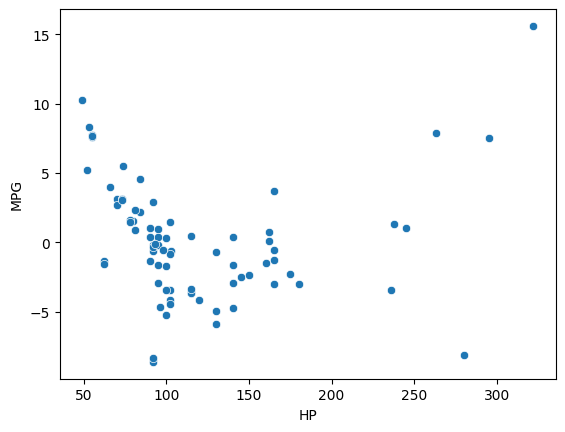

In [30]:
sns.scatterplot(data =cars_data, x = "HP", y =error)

## test 5 also failed, since it is not equal speard

## Test 6 : Zero Residual Mean Test

<function matplotlib.pyplot.show(close=None, block=None)>

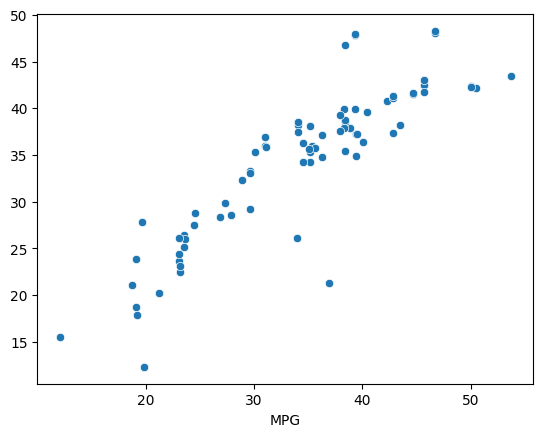

In [31]:
sns.scatterplot (x =cars_data["MPG"], y = y_pred)
plt.show

## Test 6: Zero Residual Mean Test is also Failed

## 9. Model Deployment

In [32]:
from pickle import dump

In [33]:
dump(obj = linear_model, file = open(file = "linear_interlligence_file.pkl", mode= "wb"))

In [34]:
from pickle import load

In [35]:
linear_intel_pkl = load (file = open(file = "linear_interlligence_file.pkl", mode= "rb"))
linear_intel_pkl

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-0.21,-0.34, 0.4 , 0.4 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['HP','VOL','SP','WT']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,30.68
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


## THE END